In [10]:
import os, re
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
import os
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import numpy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import cv2
from typing import List
from typing import List, Tuple
import os, numpy as np, nibabel as nib, torch
from torch.utils.data import Dataset
from typing import List, Tuple
import random
from collections import OrderedDict
from scipy.ndimage import center_of_mass
from collections import OrderedDict

In [11]:
class LiverDataset(Dataset):
    def __init__(self, img_folder: str, mask_folder: str, slices_to_select: List[str],
                 polar: bool = False):
        self.slices_to_select = slices_to_select
        self.img_folder = img_folder
        self.mask_folder = mask_folder
        self.polar = polar

    def __len__(self):
        return len(self.slices_to_select)

    def __getitem__(self, idx):
        # Identificadors del slice 
        current_slice_info = self.slices_to_select[idx]
        volume_info_raw = current_slice_info.split("_")[0]  # "volume-000"
        volume_idx = volume_info_raw.split("-")[1]
        slice_info_raw = current_slice_info.split("_")[1]   # "slice-0"
        slice_idx = int(slice_info_raw.split("-")[1])

        # Carreguem volum i màscara 
        img = nib.load(os.path.join(self.img_folder, f"volume-{volume_idx}.nii")).dataobj[..., slice_idx]
        img = self._normalize_ct(img.copy())

        mask = nib.load(os.path.join(self.mask_folder, f"segmentation-{volume_idx}.nii")).dataobj[..., slice_idx].copy()
        mask[mask == 2] = 1  # unim fetge i tumor

        # Guardam tamany original
        original_size = img.shape

        # Per defecte 
        center = None

        # Si volem treballar en polars
        if self.polar:
            # Centre de massa de la màscara
            if mask.sum() == 0:
                center = (mask.shape[1] // 2, mask.shape[0] // 2)
            else:
                center = self._get_center_from_mask(mask)
            #print(center)
            img, center, max_radius = self._cartesian_to_polar(img, center)
            mask, _, _ = self._cartesian_to_polar(mask, center, is_mask=True)

        # Tensors
        img_t = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask_t = torch.tensor(mask.astype(np.float32)).unsqueeze(0)

        return img_t, mask_t, center, current_slice_info


    # Funcions Auxiliars

    @staticmethod
    def _normalize_ct(ct_image: np.ndarray) -> np.ndarray:
        """
        Normalitza la imatge CT a l'interval [0, 1] després de retallar
        els valors de densitat (HU) a l'interval [-200, 250].
        """
        clip_range = (-200, 250)
        img = np.clip(ct_image, *clip_range)
        img = (img - clip_range[0]) / (clip_range[1] - clip_range[0])
        return np.nan_to_num(img, nan=0.0).astype(np.float32)

    @staticmethod
    def _get_center_from_mask(mask_np: np.ndarray):
        """
        Retorna un centre geomètric segur per a la màscara.
        Si està buida o conté NaN, retorna el centre de la imatge.
        """
        h, w = mask_np.shape
        cy, cx = center_of_mass(mask_np)
        if np.isnan(cx) or np.isnan(cy):
            return (w // 2, h // 2)
        return (int(round(cx)), int(round(cy)))

    @staticmethod
    def _cartesian_to_polar(img_np: np.ndarray, center=None, is_mask=False):
        """
        Converteix una imatge cartesiana a coordenades polars.
        Manté la mateixa mida que l'original.
        Si és màscara, empra interpolació nearest per evitar valors continus.
        """
        h, w = img_np.shape[:2]

        # Centre geomètric
        if center is None:
            mask_bin = (img_np > 0).astype(np.uint8)
            m = cv2.moments(mask_bin)
            if m["m00"] > 0:
                cx = m["m10"] / m["m00"]
                cy = m["m01"] / m["m00"]
                center = (float(cx), float(cy))
            else:
                center = (w / 2.0, h / 2.0)

        cx, cy = center

        # Radi màxim real 
        distances = [
            np.hypot(cx - 0, cy - 0),
            np.hypot(cx - w, cy - 0),
            np.hypot(cx - 0, cy - h),
            np.hypot(cx - w, cy - h),
        ]
        max_radius = float(max(distances))

        # Flags i interpolació 
        flags = cv2.WARP_POLAR_LINEAR | cv2.WARP_FILL_OUTLIERS
        interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR

        # Conversió
        polar = cv2.warpPolar(
            img_np.astype(np.float32),
            (w, h),
            (cx, cy),
            max_radius,
            flags
        )

        polar = np.nan_to_num(polar, nan=0.0).astype(np.float32)
        if is_mask:
            polar = (polar > 0.5).astype(np.float32)

        return polar, center, max_radius

    @staticmethod
    def polar_to_cartesian(polar_np: np.ndarray, center, max_radius, out_shape, is_mask=False):
        """
        Converteix una imatge polar a cartesiana, mantenint el radi i centre originals.
        """
        h, w = out_shape
        flags = cv2.WARP_INVERSE_MAP | cv2.WARP_POLAR_LINEAR | cv2.WARP_FILL_OUTLIERS
        interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR

        cart = cv2.warpPolar(
            polar_np.astype(np.float32),
            (w, h),
            center,
            max_radius,
            flags
        )

        cart = np.nan_to_num(cart, nan=0.0).astype(np.float32)
        if is_mask:
            cart = (cart > 0.5).astype(np.float32)

        return cart


In [12]:
DATASET_PATH = r"/home/ang2025/TFG_Angela/LiTS(train_test)"

# Rutas 
img_folder_train = os.path.join(DATASET_PATH, "train_CT")
mask_folder_train = os.path.join(DATASET_PATH, "train_mask")
img_folder_val   = os.path.join(DATASET_PATH, "val_CT")
mask_folder_val  = os.path.join(DATASET_PATH, "val_mask")

# Llistes de slices
with open(os.path.join(DATASET_PATH, "train_slices.txt"), "r") as f:
    slices_to_select_train = [line.strip() for line in f]

with open(os.path.join(DATASET_PATH, "val_slices.txt"), "r") as f:
    slices_to_select_val = [line.strip() for line in f]


# Dataset Cartesiá - Per comparar
train_dataset = LiverDataset(
    img_folder=img_folder_train,
    mask_folder=mask_folder_train,
    slices_to_select=slices_to_select_train,
    polar=False
)

val_dataset = LiverDataset(
    img_folder=img_folder_val,
    mask_folder=mask_folder_val,
    slices_to_select=slices_to_select_val,
    polar=False
)

# Dataset Polar - Per entrenar
train_dataset_polar = LiverDataset(
    img_folder=img_folder_train,
    mask_folder=mask_folder_train,
    slices_to_select=slices_to_select_train,
    polar=True
)

val_dataset_polar = LiverDataset(
    img_folder=img_folder_val,
    mask_folder=mask_folder_val,
    slices_to_select=slices_to_select_val,
    polar=True
)

# Dataloaders
batch_size = 8  

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

train_loader_polar = DataLoader(
    train_dataset_polar,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader_polar = DataLoader(
    val_dataset_polar,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Verificam
print(f"Datasets carregats correctament:")
print(f" - Cartesian train: {len(train_dataset)} slices")
print(f" - Cartesian val:   {len(val_dataset)} slices")
print(f" - Polar train:     {len(train_dataset_polar)} slices")
print(f" - Polar val:       {len(val_dataset_polar)} slices")


Datasets carregats correctament:
 - Cartesian train: 31982 slices
 - Cartesian val:   14422 slices
 - Polar train:     31982 slices
 - Polar val:       14422 slices


In [13]:
def plot_mask_polar_transform(dataset, num_slices=3, seed=42):
    """
    Mostra diverses slices amb:
    1. Imatge cartesiana original (amb punt roig del centre)
    2. Màscara cartesiana (amb punt roig del centre)
    3. Màscara en coordenades polars
    4. Màscara reconstruïda de polar a cartesiana
    """

    random.seed(seed)
    random_idxs = random.sample(range(len(dataset)), num_slices)
    fig, axs = plt.subplots(num_slices, 4, figsize=(18, 4 * num_slices))

    for i, idx in enumerate(random_idxs):
        # Carregam dades 
        img_t, mask_t, _, name = dataset[idx]
        img = img_t.squeeze().numpy()
        mask = mask_t.squeeze().numpy()

        # Centre segur 
        if mask.sum() == 0:
            center = (mask.shape[1] // 2, mask.shape[0] // 2)
        else:
            center = LiverDataset._get_center_from_mask(mask)

        # Transformacions
        mask_polar, center, max_radius = LiverDataset._cartesian_to_polar(mask, center=center, is_mask=True)
        mask_reconstructed = LiverDataset.polar_to_cartesian(
            mask_polar,
            center=center,
            max_radius=max_radius,
            out_shape=mask.shape,
            is_mask=True
        )

        # Visualització 
        cx, cy = center  # per claredat visual

        # (1) Imatge CT
        axs[i, 0].imshow(img, cmap='gray')
        axs[i, 0].scatter(cx, cy, c='red', s=30, marker='x')  # punt roig
        axs[i, 0].set_title(f"Imatge CT\n{name}")
        axs[i, 0].axis('off')

        # (2) Màscara cartesiana
        axs[i, 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axs[i, 1].scatter(cx, cy, c='red', s=30, marker='x')
        axs[i, 1].set_title("Màscara cartesiana")
        axs[i, 1].axis('off')

        # (3) Màscara en coordenades polars
        axs[i, 2].imshow(mask_polar, cmap='gray', aspect='auto', interpolation='nearest')
        axs[i, 2].set_title("Màscara en coordenades polars")
        axs[i, 2].axis('off')

        # (4) Màscara reconstruïda
        axs[i, 3].imshow(mask_reconstructed, cmap='gray', vmin=0, vmax=1)
        axs[i, 3].scatter(cx, cy, c='red', s=30, marker='x')
        axs[i, 3].set_title("Màscara reconstruïda\n(polar → cartesiana)")
        axs[i, 3].axis('off')

    plt.tight_layout()
    plt.show()


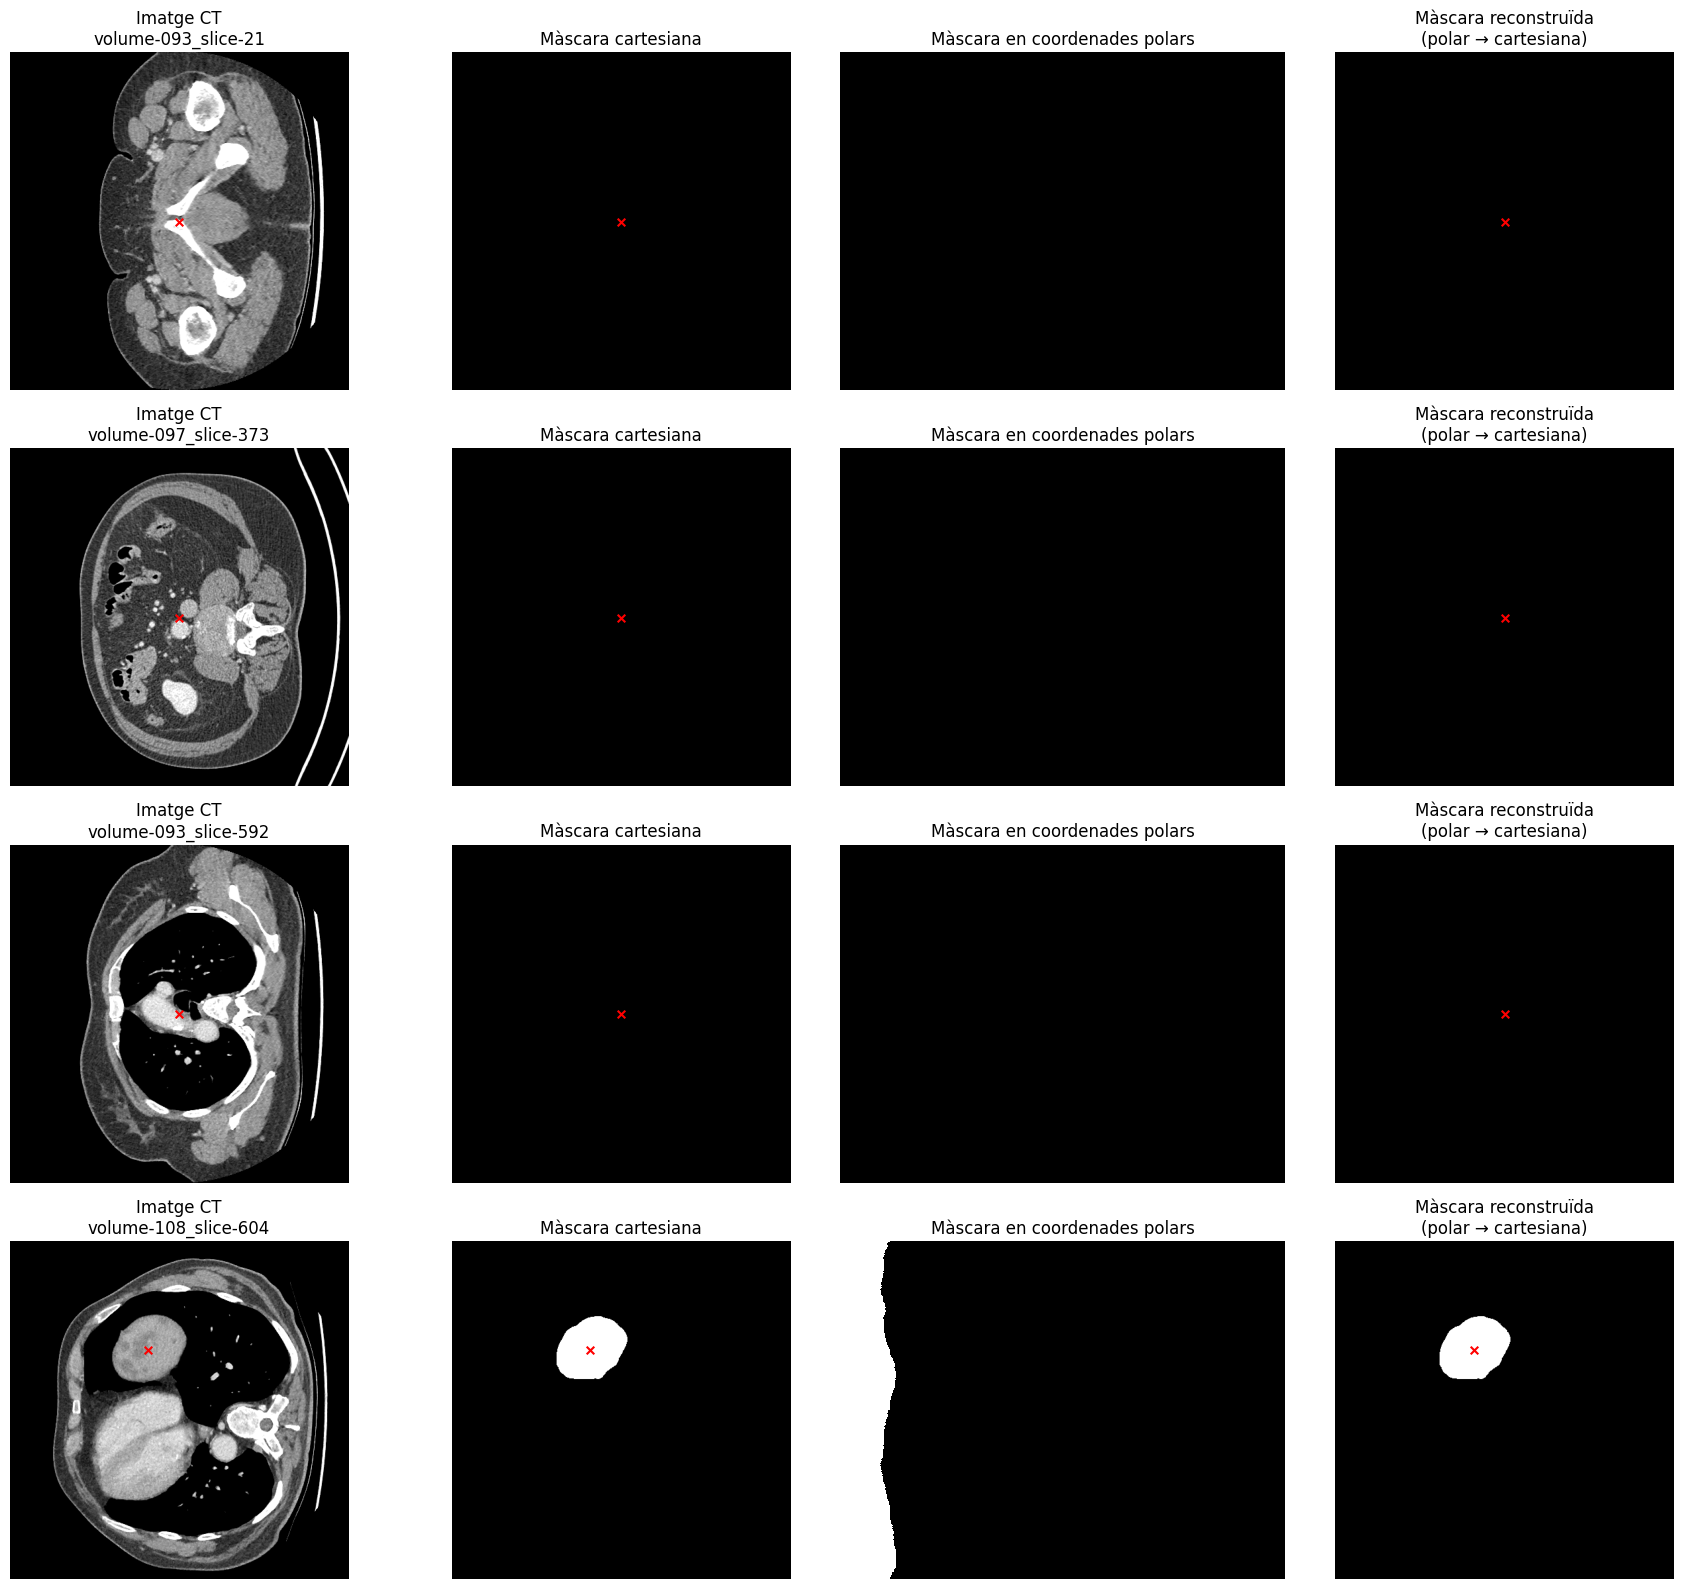

In [5]:
plot_mask_polar_transform(val_dataset, num_slices=4, seed=123)


In [14]:
#Definim la Clase DiceLoss
class DiceLoss(nn.Module):

    def __init__(self):
        super(DiceLoss, self).__init__()
        self.smooth = 1.0

    def forward(self, y_pred, y_true):
        assert y_pred.size() == y_true.size()
        dscs = torch.zeros(y_pred.shape[1], device=y_pred.device)

        for i in range(y_pred.shape[1]):
          y_pred_ch = y_pred[:, i].contiguous().view(-1)
          y_true_ch = y_true[:, i].contiguous().view(-1)
          intersection = (y_pred_ch * y_true_ch).sum()
          dscs[i] = (2. * intersection + self.smooth) / (
              y_pred_ch.sum() + y_true_ch.sum() + self.smooth
          )
        return 1. - torch.mean(dscs)


In [15]:
def compute_iou(y_true, y_pred, smooth=1e-6):
    """
    IoU medio por clase para segmentación multiclase.
    y_true, y_pred: tensores one-hot de tamaño (B, C, H, W) con 0/1.
    """
    ious = []
    for c in range(y_true.shape[1]):
        y_t = y_true[:, c].float()
        y_p = y_pred[:, c].float()
        intersection = (y_t * y_p).sum()
        union = y_t.sum() + y_p.sum() - intersection
        ious.append((intersection + smooth) / (union + smooth))
    return torch.mean(torch.stack(ious))


def compute_precision(y_true, y_pred, smooth=1e-3):
    """
    Precisión media por clase para segmentación multiclase.
    y_true, y_pred: tensores one-hot de tamaño (B, C, H, W) con 0/1.
    """
    precisions = []
    for c in range(y_true.shape[1]):
        y_t = y_true[:, c].float()
        y_p = y_pred[:, c].float()
        true_positive = (y_t * y_p).sum()
        predicted_positive = y_p.sum()
        precisions.append((true_positive + smooth) / (predicted_positive + smooth))
    return torch.mean(torch.stack(precisions))



def compute_dice_coefficient(y_true, y_pred, smooth=1.0):

    y_true = y_true.contiguous().view(y_true.shape[0], -1)
    y_pred = y_pred.contiguous().view(y_pred.shape[0], -1)

    intersection = (y_true * y_pred).sum(dim=1)
    union = y_true.sum(dim=1) + y_pred.sum(dim=1)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()


In [16]:
#Definim la RedUnet
class UNet(nn.Module):

  def __init__(self, device, in_channels=1, out_channels=1, init_features=32):
    super(UNet, self).__init__()
    #self.device = device
    
    features = init_features
    self.encoder1 = UNet._block(in_channels, features, name="enc1")
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.encoder2 = UNet._block(features, features * 2, name="enc2")
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.encoder5 = UNet._block(features * 8, features * 16, name="enc5")
    self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.bottleneck = UNet._block(features * 16, features * 32, name="bottleneck")

    self.upconv5 = nn.ConvTranspose2d(features * 32, features * 16, kernel_size=2, stride=2)
    self.decoder5 = UNet._block(features * 32, features * 16, name="dec5")

    
    self.upconv4 = nn.ConvTranspose2d(
      features * 16, features * 8, kernel_size=2, stride=2
    )
    self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
    self.upconv3 = nn.ConvTranspose2d(
      features * 8, features * 4, kernel_size=2, stride=2
    )

    self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
    self.upconv2 = nn.ConvTranspose2d(
      features * 4, features * 2, kernel_size=2, stride=2
    )
    self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
    self.upconv1 = nn.ConvTranspose2d(
      features * 2, features, kernel_size=2, stride=2
    )
    self.decoder1 = UNet._block(features * 2, features, name="dec1")

    self.conv = nn.Conv2d(
      in_channels=features, out_channels=out_channels, kernel_size=1
    )



  def forward(self, x):
    enc1 = self.encoder1(x)
    enc2 = self.encoder2(self.pool1(enc1))
    enc3 = self.encoder3(self.pool2(enc2))
    enc4 = self.encoder4(self.pool3(enc3))
    enc5 = self.encoder5(self.pool4(enc4))

    bottleneck = self.bottleneck(self.pool5(enc5))

    dec5 = self.decoder5(torch.cat((self.upconv5(bottleneck), enc5), dim=1))
    dec4 = self.decoder4(torch.cat((self.upconv4(dec5), enc4), dim=1))
    dec3 = self.decoder3(torch.cat((self.upconv3(dec4), enc3), dim=1))
    dec2 = self.decoder2(torch.cat((self.upconv2(dec3), enc2), dim=1))
    dec1 = self.decoder1(torch.cat((self.upconv1(dec2), enc1), dim=1))

      
    return torch.sigmoid(self.conv(dec1))


  @staticmethod
  def _block(in_channels, features, name):
    return nn.Sequential(
      OrderedDict(
        [
          (
            name + "conv1",
            nn.Conv2d(
              in_channels=in_channels,
              out_channels=features,
              kernel_size=3,
              padding=1,
              bias=False,
            ),
          ),
          (name + "norm1", nn.BatchNorm2d(num_features=features)),
          (name + "relu1", nn.ReLU(inplace=True)),
          (
            name + "conv2",
            nn.Conv2d(
              in_channels=features,
              out_channels=features,
              kernel_size=3,
              padding=1,
              bias=False,
            ),
          ),
          (name + "norm2", nn.BatchNorm2d(num_features=features)),
          (name + "relu2", nn.ReLU(inplace=True)),
        ]
      )
    )

In [ ]:
# Configuració
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 30
early_stopping_patience = 8
caract_model = 16

resultats_path = './Resultats'
notebooks_path = './Notebooks'
os.makedirs(resultats_path, exist_ok=True)
os.makedirs(notebooks_path, exist_ok=True)

# Model
model = UNet(
    device=device, 
    in_channels=1, 
    out_channels=1,
    init_features=caract_model
).to(device)

criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)

# Históric
train_losses, val_losses, train_iou, train_precision = [], [], [], []
val_dice_list, val_iou_list, val_prec_list = [], [], []
val_losses_bin, val_dice_list_bin, val_iou_list_bin, val_prec_list_bin = [], [], [], []
best_val_loss = float('inf')
epochs_no_improve = 0

# Entrenament polar
for epoch in range(num_epochs):
    print(f"Época {epoch + 1}/{num_epochs} (entrenament en coordenades polars)")

    # TRAIN
    model.train()
    running_loss = 0.0
    dice_scores, iou_scores, precision_scores = [], [], []

    for batch_img, batch_mask, _, _ in tqdm(train_loader_polar, desc="Entrenando (Polar)"):
        batch_img, batch_mask = batch_img.to(device), batch_mask.to(device)
        optimizer.zero_grad()

        outputs = model(batch_img)


        # Dice loss sobre predicciones "soft"
        loss = criterion(outputs, batch_mask)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Métriques de entrenamiento
        with torch.no_grad():
            dice_scores.append(1.0 - loss.item())
            iou_scores.append(compute_iou(batch_mask, outputs).item())
            precision_scores.append(compute_precision(batch_mask, outputs).item())

    avg_train_loss = running_loss / len(train_loader_polar)
    avg_train_dice = sum(dice_scores) / len(dice_scores)
    avg_train_iou = sum(iou_scores) / len(iou_scores)
    avg_train_precision = sum(precision_scores) / len(precision_scores)
    train_losses.append(avg_train_loss)
    train_iou.append(avg_train_iou)
    train_precision.append(avg_train_precision)

    print(f"Train DiceLoss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | IoU: {avg_train_iou:.4f} | Precision: {avg_train_precision:.4f}")

    # Validació
    model.eval()
    val_running_loss = 0.0
    val_running_loss_bin = 0.0
    dice_scores, iou_scores, precision_scores = [], [], []
    dice_scores_bin, iou_scores_bin, precision_scores_bin = [], [], []

    with torch.no_grad():
        for val_img, val_mask, _, _ in val_loader_polar:
            val_img, val_mask = val_img.to(device), val_mask.to(device)
            val_output = model(val_img)
            pred_bin = (val_output > 0.5).float()

            # Pèrdues
            val_loss = criterion(val_output, val_mask)
            val_loss_bin = criterion(pred_bin, val_mask)
            val_running_loss += val_loss.item()
            val_running_loss_bin += val_loss_bin.item()

            # Métriques
            dice_scores.append(1.0 - val_loss.item())
            dice_scores_bin.append(1.0 - val_loss_bin.item())
            iou_scores.append(compute_iou(val_mask, val_output).item())
            iou_scores_bin.append(compute_iou(val_mask, pred_bin).item())
            precision_scores.append(compute_precision(val_mask, val_output).item())
            precision_scores_bin.append(compute_precision(val_mask, pred_bin).item())

    avg_val_loss = val_running_loss / len(val_loader_polar)
    avg_val_loss_bin = val_running_loss_bin / len(val_loader_polar)
    avg_val_dice = sum(dice_scores) / len(dice_scores)
    avg_val_dice_bin = sum(dice_scores_bin) / len(dice_scores_bin)
    avg_val_iou = sum(iou_scores) / len(iou_scores)
    avg_val_iou_bin = sum(iou_scores_bin) / len(iou_scores_bin)
    avg_val_precision = sum(precision_scores) / len(precision_scores)
    avg_val_precision_bin = sum(precision_scores_bin) / len(precision_scores_bin)

    val_losses.append(avg_val_loss)
    val_losses_bin.append(avg_val_loss_bin)
    val_dice_list.append(avg_val_dice)
    val_dice_list_bin.append(avg_val_dice_bin)
    val_iou_list.append(avg_val_iou)
    val_iou_list_bin.append(avg_val_iou_bin)
    val_prec_list.append(avg_val_precision)
    val_prec_list_bin.append(avg_val_precision_bin)

    print(f"Val DiceLoss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f} | Precision: {avg_val_precision:.4f}")
    print(f"Val Bin DiceLoss: {avg_val_loss_bin:.4f} | Dice: {avg_val_dice_bin:.4f} | IoU: {avg_val_iou_bin:.4f} | Precision: {avg_val_precision_bin:.4f}")

    # Scheduler i Early Stopping
    scheduler.step(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(notebooks_path, f'Unet_Polar_prof5_{caract_model}.pth'))
        print("Modelo mejorado")
    else:
        epochs_no_improve += 1
        print(f"No mejora. Epochs sin mejora: {epochs_no_improve}")

    if epochs_no_improve >= early_stopping_patience:
        print("Early stopping activado.")
        break

# Guardam Históric
history = {
    "num_epochs_unet_polar": num_epochs,
    "train_losses_unet_polar": train_losses,
    "val_losses_unet_polar": val_losses,
    "train_iou_unet_polar": train_iou,
    "train_precision_unet_polar": train_precision,
    "val_iou_unet_polar": val_iou_list,
    "val_precision_unet_polar": val_prec_list,
    "val_losses_unet_polar_bin": val_losses_bin,
    "val_iou_unet_polar_bin": val_iou_list_bin,
    "val_precision_unet_polar_bin": val_prec_list_bin,
}
torch.save(history, "./Notebooks/unet_training_history_Polar_UNet.pth")
print("Historial guardado correctamente.")


/opt/environment/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Época 1/30 (entrenament en coordenades polars)


Entrenando (Polar):  94%|█████████▎| 3739/3998 [15:00<00:47,  5.49it/s]

Val DiceLoss: 0.8366 | Dice: 0.1634 | IoU: 0.1167 | Precision: 0.1172
Val Bin DiceLoss: 0.6620 | Dice: 0.3380 | IoU: 0.2845 | Precision: 0.2870
Modelo mejorado
Época 2/30 (entrenament en coordenades polars)


Entrenando (Polar):  75%|███████▍  | 2998/3998 [09:06<03:01,  5.49it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Entrenando (Polar): 100%|██████████| 3998/3998 [12:07<00:00,  5.49it/s]

...

Val DiceLoss: 0.6825 | Dice: 0.3175 | IoU: 0.2830 | Precision: 0.2951
Val Bin DiceLoss: 0.0847 | Dice: 0.9153 | IoU: 0.9021 | Precision: 0.9141
No mejora. Epochs sin mejora: 1
Época 28/30 (entrenament en coordenades polars)


Entrenando (Polar): 100%|██████████| 3998/3998 [12:07<00:00,  5.49it/s]

Train DiceLoss: 0.0428 | Dice: 0.9572 | IoU: 0.9458 | Precision: 0.9559


Val DiceLoss: 0.6762 | Dice: 0.3238 | IoU: 0.2859 | Precision: 0.2971
Val Bin DiceLoss: 0.1329 | Dice: 0.8671 | IoU: 0.8545 | Precision: 0.8657
Modelo mejorado
Época 29/30 (entrenament en coordenades polars)


Entrenando (Polar):  24%|██▍       | 967/3998 [02:56<09:11,  5.49it/s]

In [17]:
# Carreguem el model coordenades polars
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
caract_model = 16  # mateix valor que en l'entrenament

model = UNet(device=device, in_channels=1, out_channels=1, init_features=caract_model).to(device)
model_path = f"./Notebooks/Unet_Polar_prof5_{caract_model}.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model Polar carregat correctament")

# Carreguem l'historial polar
history = torch.load("./Notebooks/unet_training_history_Polar_UNet.pth")

train_losses_polar = history['train_losses_unet_polar']
val_losses_polar   = history['val_losses_unet_polar']
train_iou_polar    = history['train_iou_unet_polar']
val_iou_polar      = history['val_iou_unet_polar']
train_prec_polar   = history['train_precision_unet_polar']
val_precision_polar = history['val_precision_unet_polar']
val_losses_bin_polar   = history['val_losses_unet_polar_bin']
val_iou_bin_polar      = history['val_iou_unet_polar_bin']
val_precision_bin_polar= history['val_precision_unet_polar_bin']

print("Historial polar carregat correctament")


Model Polar carregat correctament
Historial polar carregat correctament


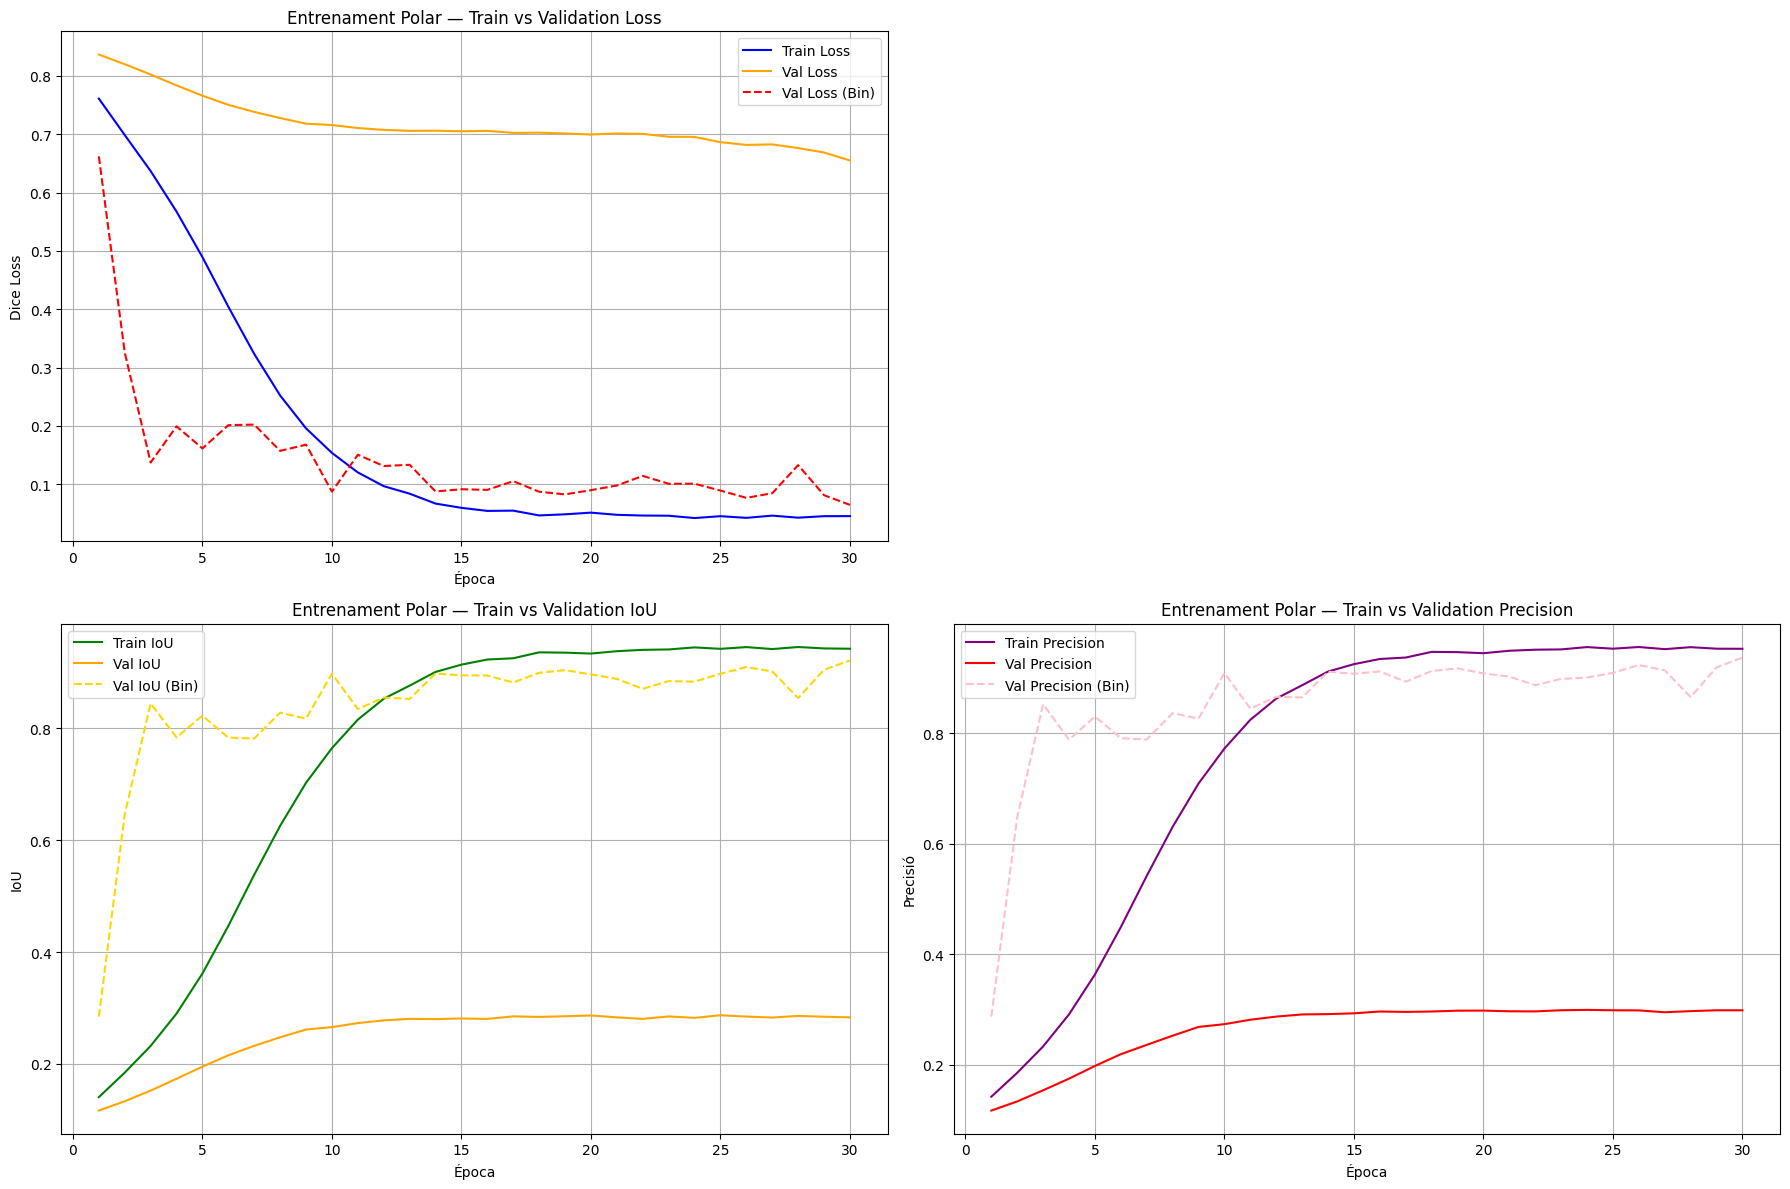

In [12]:
plt.figure(figsize=(18, 12))
num_epochs =30
epochs = range(1, num_epochs + 1)


# Pèrdua (Dice Loss)
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses_polar, label='Train Loss', color='blue')
plt.plot(epochs, val_losses_polar, label='Val Loss', color='orange')
plt.plot(epochs, val_losses_bin_polar, '--', label='Val Loss (Bin)', color='red')
plt.xlabel('Época')
plt.ylabel('Dice Loss')
plt.title('Entrenament Polar — Train vs Validation Loss')
plt.legend()
plt.grid(True)

# IoU
plt.subplot(2, 2, 3)
plt.plot(epochs, train_iou_polar, label='Train IoU', color='green')
plt.plot(epochs, val_iou_polar, label='Val IoU', color='orange')
plt.plot(epochs, val_iou_bin_polar, '--', label='Val IoU (Bin)', color='gold')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('Entrenament Polar — Train vs Validation IoU')
plt.legend()
plt.grid(True)

# Precisió
plt.subplot(2, 2, 4)
plt.plot(epochs, train_prec_polar, label='Train Precision', color='purple')
plt.plot(epochs, val_precision_polar, label='Val Precision', color='red')
plt.plot(epochs, val_precision_bin_polar, '--', label='Val Precision (Bin)', color='pink')
plt.xlabel('Época')
plt.ylabel('Precisió')
plt.title('Entrenament Polar — Train vs Validation Precision')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


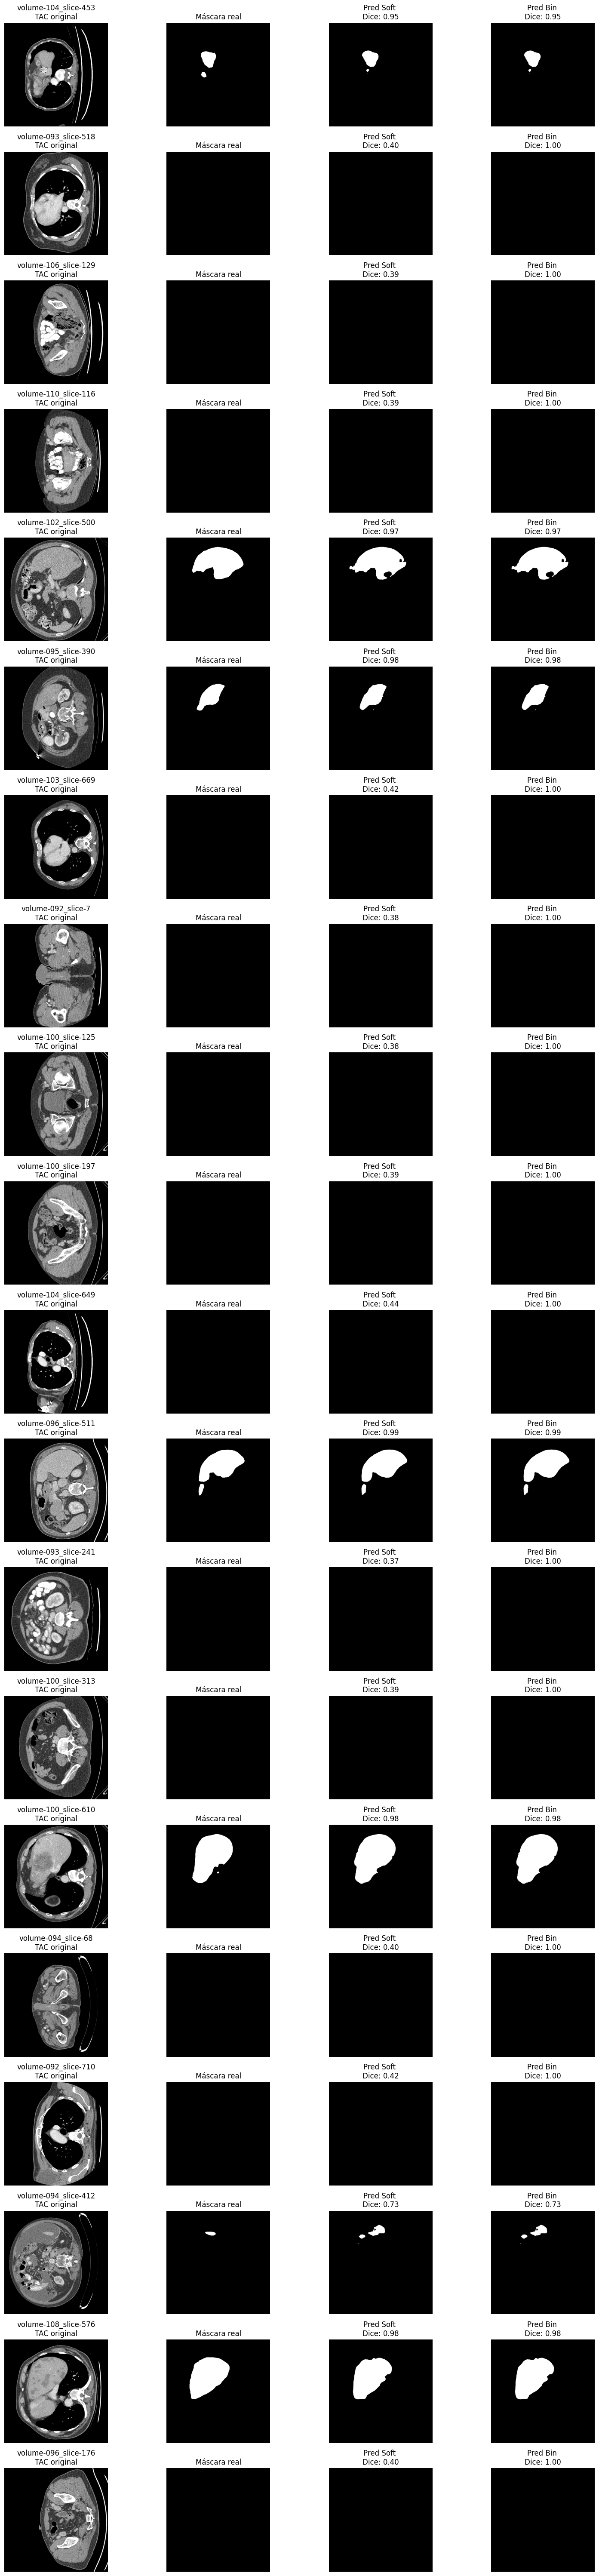

<Figure size 640x480 with 0 Axes>

In [19]:
# Configuració 
number_samples_to_show = 20
random.seed(2025)
random_idxs = random.sample(range(len(val_dataset)), number_samples_to_show)

dice_loss = DiceLoss()
model.eval()

# Figura amb 4 columnes
fig, axs = plt.subplots(number_samples_to_show, 4, figsize=(16, 3*number_samples_to_show))

for i, idx in enumerate(random_idxs):
    # --- Carregam dades reals (cartesianes) ---
    img_cart_t, mask_cart_t, _, slice_name = val_dataset[idx]
    img_cart = img_cart_t.squeeze().numpy()
    mask_cart = mask_cart_t.squeeze().numpy()

    # --- Obtenim la mateixa slice però en polar ---
    img_polar_t, mask_polar_t, center, _ = val_dataset_polar[idx]
    img_polar = img_polar_t.unsqueeze(0).to(device)
    mask_polar = mask_polar_t.to(device)

    with torch.no_grad():
        pred_soft_polar = model(img_polar)
        pred_bin_polar  = (pred_soft_polar > 0.5).float()

    # --- Convertim de polar a cartesiana només les prediccions ---
    h, w = img_cart.shape
    cx, cy = center
    max_radius = float(np.sqrt(max(cx, w - cx)**2 + max(cy, h - cy)**2))



    pred_soft_cart = LiverDataset.polar_to_cartesian(
        pred_soft_polar.squeeze().cpu().numpy(),
        center=center,
        max_radius=max_radius,
        out_shape=(h, w),
        is_mask=False
    )

    pred_bin_cart = LiverDataset.polar_to_cartesian(
        pred_bin_polar.squeeze().cpu().numpy(),
        center=center,
        max_radius=max_radius,
        out_shape=(h, w),
        is_mask=True
    )
    
    H, W = mask_cart.shape
    pred_soft_cart = cv2.resize(pred_soft_cart, (W, H), interpolation=cv2.INTER_LINEAR)
    pred_bin_cart  = cv2.resize(pred_bin_cart,  (W, H), interpolation=cv2.INTER_NEAREST)

    

    # Mètriques (calculades en polars)
    dice_soft = 1 - dice_loss(pred_soft_polar, mask_polar.unsqueeze(0)).item()
    dice_bin  = 1 - dice_loss(pred_bin_polar, mask_polar.unsqueeze(0)).item()

    axs[i, 0].imshow(img_cart, cmap='gray')
    axs[i, 0].set_title(f'{slice_name}\nTAC original')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(mask_cart, cmap='gray', vmin=0, vmax=1)
    axs[i, 1].set_title('Máscara real')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(pred_soft_cart, cmap='gray', vmin=0, vmax=1)
    axs[i, 2].set_title(f'Pred Soft \nDice: {dice_soft:.2f}')
    axs[i, 2].axis('off')

    axs[i, 3].imshow(pred_bin_cart, cmap='gray', vmin=0, vmax=1)
    axs[i, 3].set_title(f'Pred Bin \nDice: {dice_bin:.2f}')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()

# Guardar figura
plt.savefig('./Notebooks/predicciones_val_dataset_CART_reales.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
def get_best_metrics(history):
    val_losses = history[f"val_losses_unet_polar_bin"]
    best_epoch = np.argmin(val_losses)
    dice = 1 - val_losses[best_epoch]
    iou = history[f"val_iou_unet_polar_bin"][best_epoch]
    precision = history[f"val_precision_unet_polar_bin"][best_epoch]
    return dice, iou, precision
dice, iou, prec = get_best_metrics(history)
round(dice, 2), round(iou, 2), round(prec, 2)

(0.94, 0.92, 0.94)